In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("/content/ecommerce_customer_data_custom_ratios.csv")

df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.00000,250000.000000,250000.000000,250000.000000,250000.000000,202404.000000,250000.000000,250000.000000
mean,25004.03624,254.659512,2.998896,2725.370732,43.940528,0.497861,43.940528,0.199496
std,14428.27959,141.568577,1.414694,1442.933565,15.350246,0.499997,15.350246,0.399622
min,1.00000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000
25%,12497.75000,132.000000,2.000000,1477.000000,31.000000,0.000000,31.000000,0.000000
50%,25018.00000,255.000000,3.000000,2724.000000,44.000000,0.000000,44.000000,0.000000
75%,37506.00000,377.000000,4.000000,3974.000000,57.000000,1.000000,57.000000,0.000000
max,50000.00000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000


In [4]:
df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,47596
Customer Name,0


In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.fillna(df.median(numeric_only=True), inplace=True)

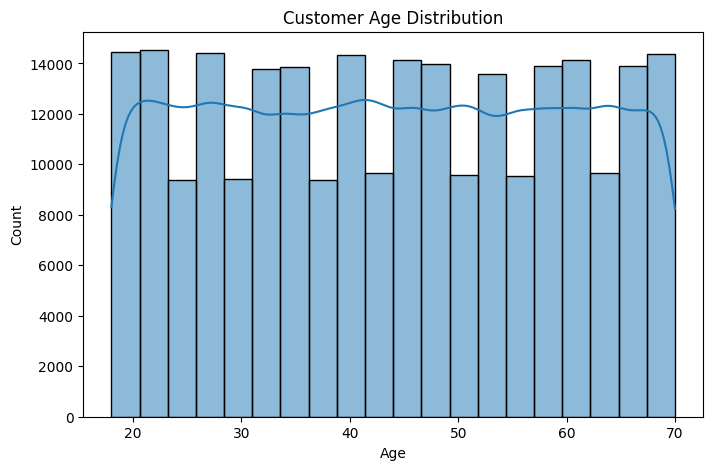

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Customer Age Distribution")
plt.show()

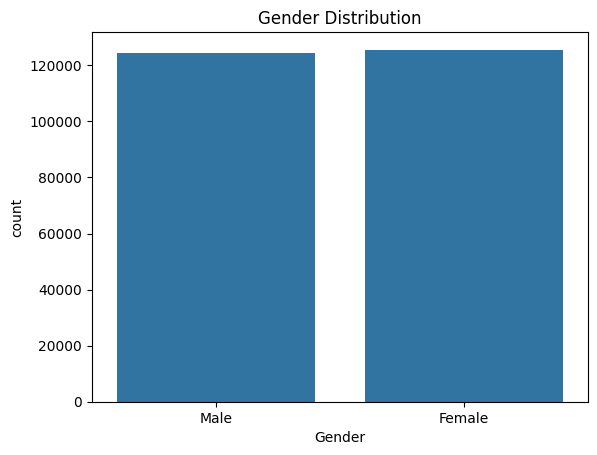

In [8]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

In [16]:
customer_df = df.groupby('Customer ID').agg({
    'Total Purchase Amount':['sum','mean'],
    'Quantity':'sum',
    'Purchase Date':'max',
    'Churn':'max'
}).reset_index()

In [18]:
customer_df.columns = [
    'Customer_ID',
    'Total_Spending',
    'Avg_Spending',
    'Total_Quantity',
    'Last_Purchase_Date',
    'Churn'
]

In [21]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

In [22]:
df['Purchase Date'].dtype

dtype('<M8[ns]')

In [23]:
snapshot_date = df['Purchase Date'].max()

rfm = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (snapshot_date - x.max()).days,
    'Total Purchase Amount': 'sum'
})

rfm.columns = ['Recency', 'Monetary']

In [24]:
rfm['Frequency'] = df.groupby('Customer ID').size()

In [25]:
snapshot_date = df['Purchase Date'].max()

rfm = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (snapshot_date - x.max()).days,
    'Customer ID': 'count',
    'Total Purchase Amount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
1,57,1,3491
2,298,3,7988
3,88,8,22587
4,126,4,8715
5,170,8,12524


In [26]:
rfm['R'] = pd.qcut(rfm['Recency'],4,labels=[4,3,2,1])
rfm['F'] = pd.qcut(rfm['Frequency'],4,labels=[1,2,3,4])
rfm['M'] = pd.qcut(rfm['Monetary'],4,labels=[1,2,3,4])

rfm['RFM_Score'] = (
    rfm['R'].astype(str)
    + rfm['F'].astype(str)
    + rfm['M'].astype(str)
)

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [28]:
X = rfm[['Recency','Frequency','Monetary']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [29]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm['Cluster'] = kmeans.fit_predict(X_scaled)

In [30]:
rfm.groupby('Cluster').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
}).round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,135.84,8.44,24494.15
1,182.65,5.72,15614.06
2,193.01,3.33,8292.91
3,718.85,2.94,7825.25


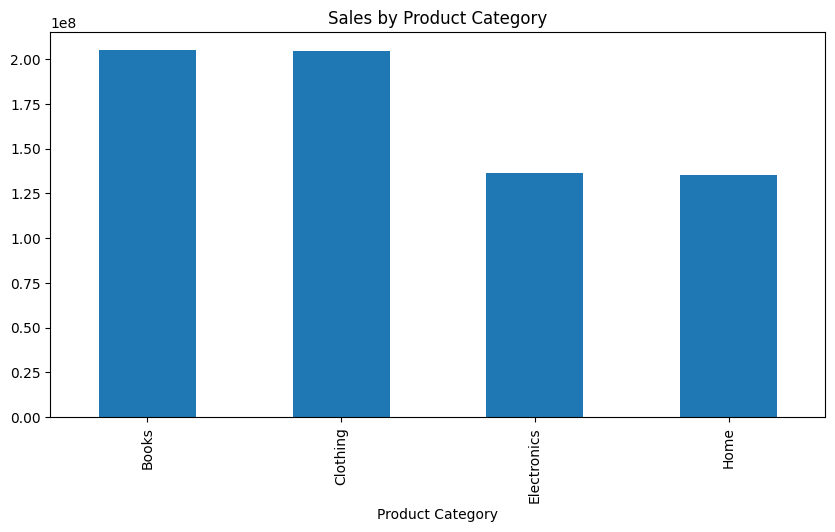

In [31]:
category_sales = df.groupby(
    'Product Category'
)['Total Purchase Amount'].sum()

category_sales.sort_values(
    ascending=False
).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Sales by Product Category")
plt.show()

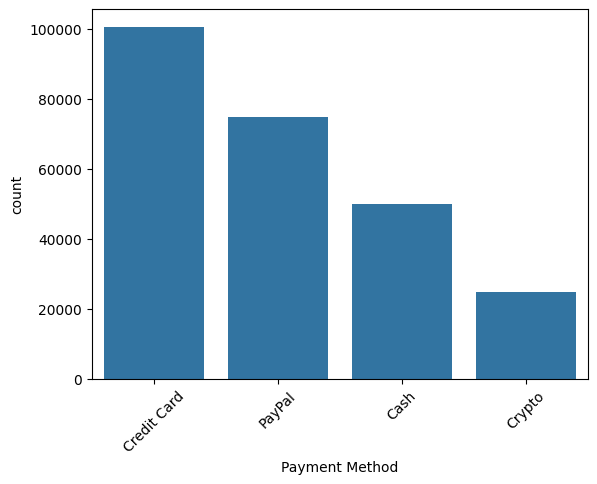

In [32]:
sns.countplot(
    x='Payment Method',
    data=df
)

plt.xticks(rotation=45)
plt.show()

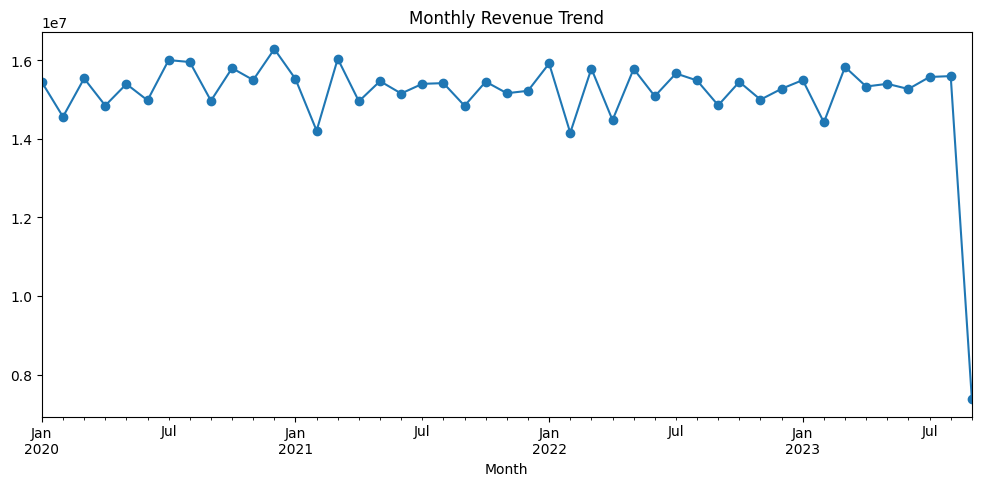

In [33]:
df['Month'] = df['Purchase Date'].dt.to_period('M')

monthly_sales = df.groupby(
    'Month'
)['Total Purchase Amount'].sum()

monthly_sales.plot(
    figsize=(12,5),
    marker='o'
)

plt.title("Monthly Revenue Trend")
plt.show()

In [34]:
df['Churn'].value_counts()

,count
Churn,
0,200126
1,49874


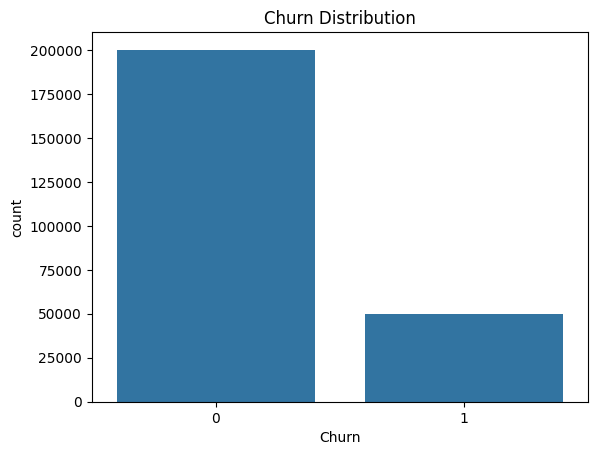

In [35]:
sns.countplot(
    x='Churn',
    data=df
)

plt.title("Churn Distribution")
plt.show()

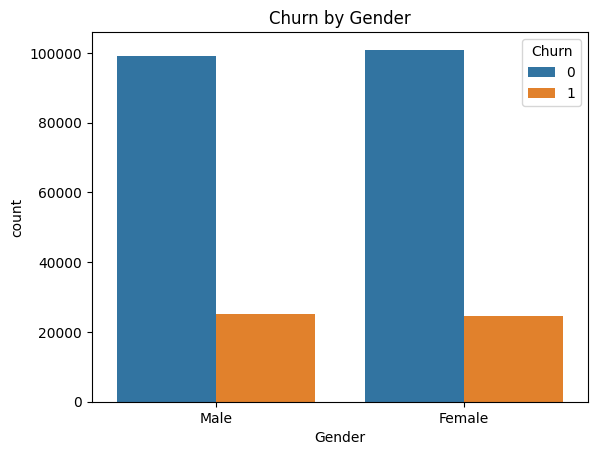

In [36]:
sns.countplot(
    x='Gender',
    hue='Churn',
    data=df
)

plt.title("Churn by Gender")
plt.show()

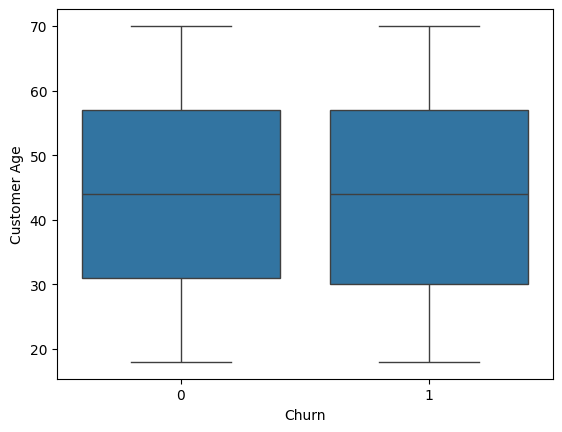

In [37]:
sns.boxplot(
    x='Churn',
    y='Customer Age',
    data=df
)

plt.show()

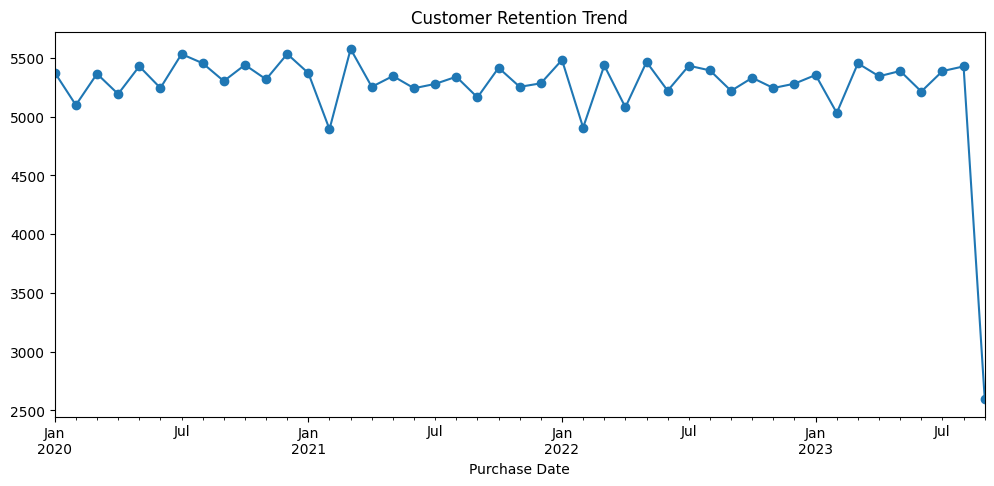

In [38]:
retention = df.groupby(
    df['Purchase Date'].dt.to_period('M')
)['Customer ID'].nunique()

retention.plot(
    figsize=(12,5),
    marker='o'
)

plt.title("Customer Retention Trend")
plt.show()

In [39]:
cluster_map = {
    0:'High Value',
    1:'Loyal',
    2:'Average',
    3:'At Risk'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_map)

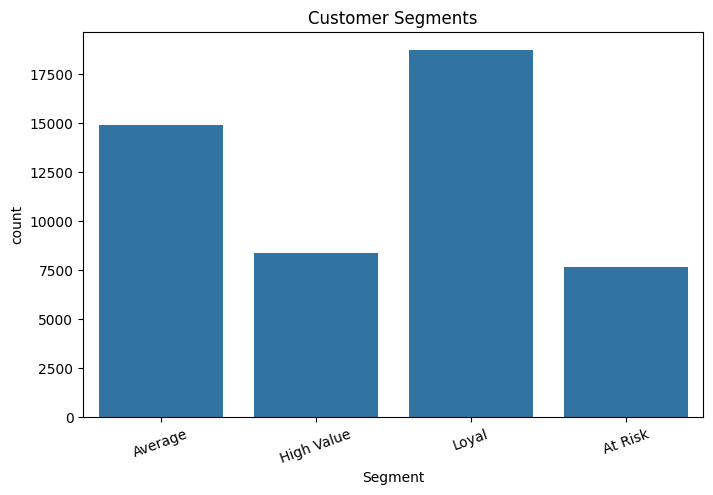

In [40]:
plt.figure(figsize=(8,5))
sns.countplot(x='Segment', data=rfm)
plt.xticks(rotation=20)
plt.title("Customer Segments")
plt.show()

In [41]:
customer_churn = df.groupby('Customer ID')['Churn'].max()

rfm['Churn'] = customer_churn

segment_churn = pd.crosstab(
    rfm['Segment'],
    rfm['Churn']
)

segment_churn

Churn,0,1
Segment,,
At Risk,6125,1524
Average,11890,3022
High Value,6690,1699
Loyal,15026,3697


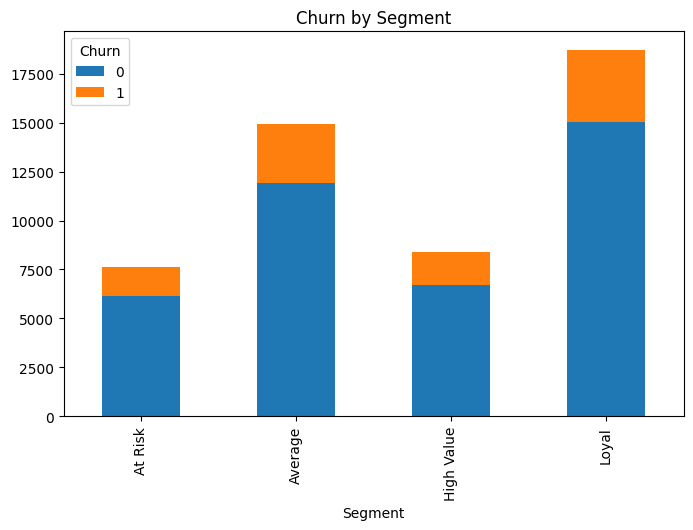

In [42]:
segment_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title("Churn by Segment")
plt.show()

In [43]:
top_categories = df.groupby(
    'Product Category'
)['Total Purchase Amount'].sum().sort_values(ascending=False)

print(top_categories)

Product Category
Books          204939601
Clothing       204532405
Electronics    136599467
Home           135271210
Name: Total Purchase Amount, dtype: int64


In [44]:
df['Returns'].value_counts()

,count
Returns,
0.0,149231
1.0,100769


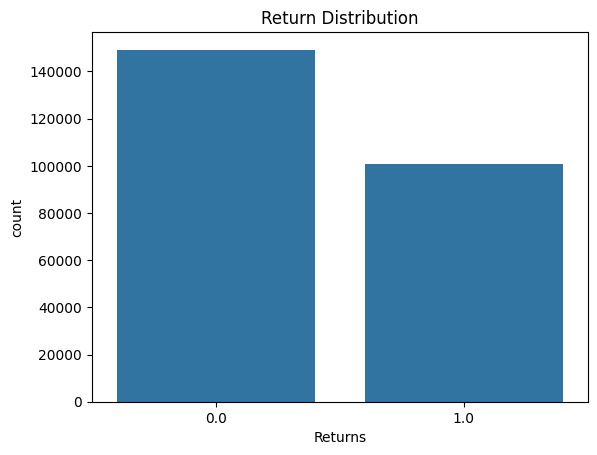

In [45]:
sns.countplot(
    x='Returns',
    data=df
)

plt.title("Return Distribution")
plt.show()

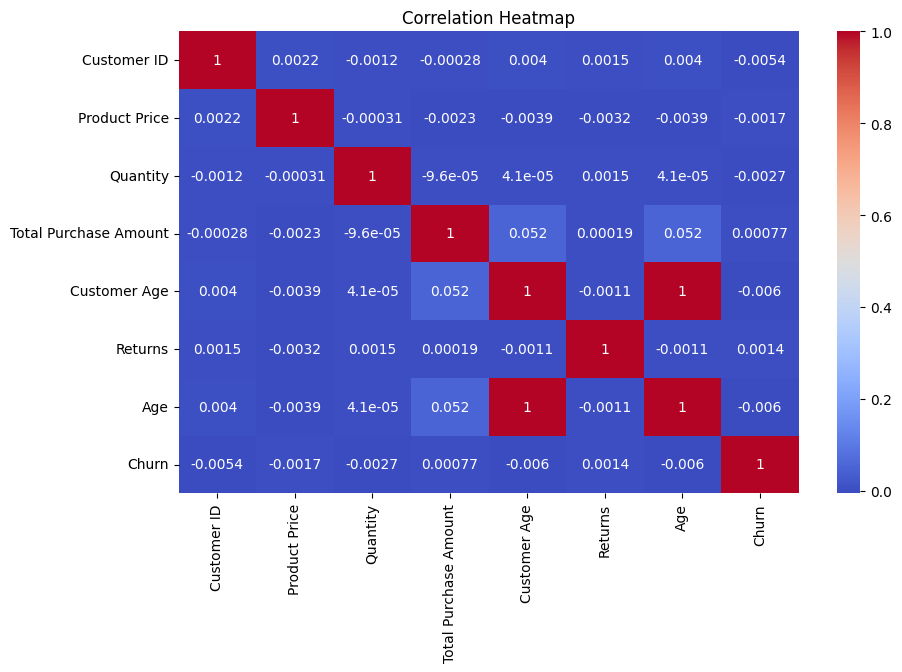

In [46]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()